# Jena Climate Data Forecasting with Keras

This notebook demonstrates how to predict future temperature values using a time-series dataset from the Jena Climate archive. We will explore different recurrent neural network (RNN) architectures, including simple LSTMs, dropout-regularized LSTMs, and stacked GRUs, to forecast temperature based on historical climate data.

In [ ]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-08-15 07:47:22--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.183.114, 16.15.238.32, 16.15.199.107, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.183.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  --.-KB/s    in 0.07s   

2026-08-15 07:47:22 (191 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


## 1. Data Loading and Initial Exploration

First, we download and extract the Jena Climate dataset, which contains various meteorological readings recorded every 10 minutes from 2009 to 2016.

In [ ]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
  data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


After loading the raw data, we inspect its structure. The dataset includes various features like pressure, temperature, humidity, and wind speed. The `temperature` array stores the 'T (degC)' values, which will be our target variable for forecasting.

In [ ]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
  values = [float(x) for x in line.split(",")[1:]]
  temperature[i] = values[1]
  raw_data[i, :] = values[:]

In [ ]:
temperature.shape

(420451,)

In [ ]:
raw_data.shape

(420451, 14)

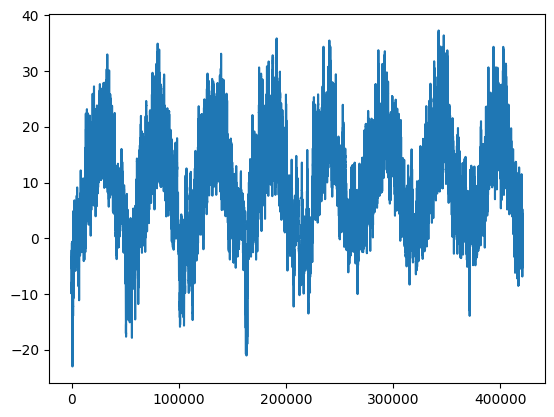

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(len(temperature)), temperature)

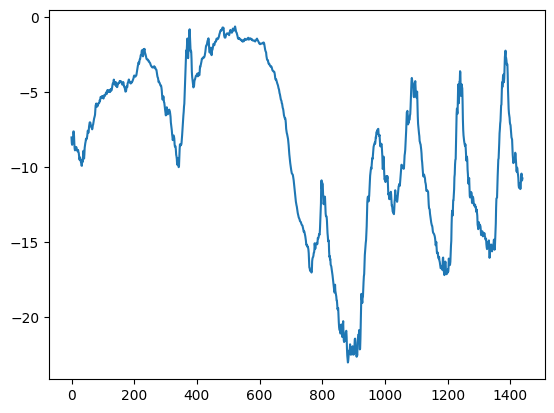

In [ ]:
#plotting the first 10 days data
plt.plot(range(1440), temperature[:1440])

In [ ]:
#50% training, 25% validation and 25% test samples
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [ ]:
#normalizing the data
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [ ]:
#testing the timeseries_dataset_from_array()
import numpy as np
from tensorflow import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
data=int_sequence[:-3],
targets=int_sequence[3:],
sequence_length=3,
batch_size=2,
)

for inputs, targets in dummy_dataset:
  for i in range(inputs.shape[0]):
    print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


### Instantiating datasets for training, validation and testing

In [ ]:
sampling_rate = 6 #observations will be sampled at one data point per hour-we'll only keep one data point out of 6
sequence_length = 120 #observations will go back to 5 days
delay = sampling_rate * (sequence_length + 24 - 1) #the target for the sequence will be the temp 24 hrs after the end of the sequence
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
  raw_data[:-delay],
  targets=temperature[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=0,
  end_index=num_train_samples,)

val_dataset = keras.utils.timeseries_dataset_from_array(
  raw_data[:-delay],
  targets=temperature[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=num_train_samples,
  end_index=num_train_samples + num_val_samples,)

test_dataset = keras.utils.timeseries_dataset_from_array(
  raw_data[:-delay],
  targets=temperature[delay:],
  sampling_rate=sampling_rate,
  sequence_length=sequence_length,
  shuffle=True,
  batch_size=batch_size,
  start_index=num_train_samples + num_val_samples,)



In [ ]:
for samples, targets in train_dataset:
  print("samples shape:", samples.shape)
  print("targets shape:", targets.shape)
  break


samples shape: (256, 120, 14)
targets shape: (256,)


In [ ]:
#defining a baseline
def evaluate_naive_method(dataset):
  total_abs_err = 0.
  samples_seen = 0
  for samples, targets in dataset:
    preds = samples[:, -1, 1] * std[1] + mean[1]
    total_abs_err += np.sum(np.abs(preds - targets))
    samples_seen += samples.shape[0]
  return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


### A simple LSTM based model

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
keras.callbacks.ModelCheckpoint("jena_lstm.keras",
save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = model.fit(train_dataset,
epochs=10,
validation_data=val_dataset,
callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 112s 133ms/step - loss: 48.8955 - mae: 5.1359 - val_loss: 15.0825 - val_mae: 2.9178
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 108s 131ms/step - loss: 11.7426 - mae: 2.6546 - val_loss: 9.5652 - val_mae: 2.3993
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 109s 132ms/step - loss: 9.9570 - mae: 2.4655 - val_loss: 9.7861 - val_mae: 2.4138
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 107s 130ms/step - loss: 9.5586 - mae: 2.4141 - val_loss: 9.6074 - val_mae: 2.3848
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 142s 130ms/step - loss: 9.3111 - mae: 2.3785 - val_loss: 9.8927 - val_mae: 2.4250
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 114s 138ms/step - loss: 9.0709 - mae: 2.3470 - val_loss: 9.9510 - val_mae: 2.4296
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 136s 131ms/step - loss: 8.8623 - mae: 2.3176 - val_loss: 10.0273 - val_mae: 2.4377
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 107s 131ms/step - loss: 8.6574 - mae: 2.2931 - val_loss: 9.8872 - val_mae: 2.4311
Epoch 9/10
819/819 ━

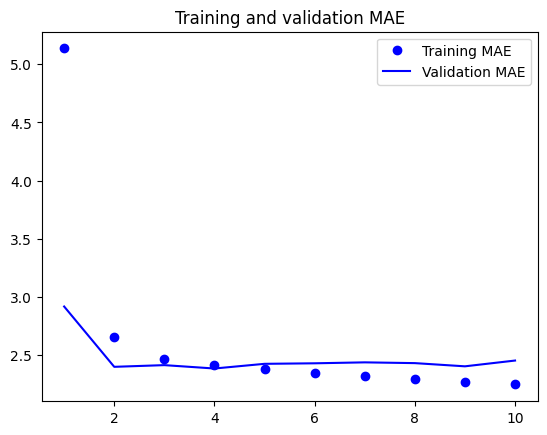

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Training and evaluating a dropout-regularized LSTM

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
epochs=50,
validation_data=val_dataset,
callbacks=callbacks)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 182s 218ms/step - loss: 30.7493 - mae: 4.0652 - val_loss: 9.6469 - val_mae: 2.4200
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 180s 219ms/step - loss: 15.0181 - mae: 3.0100 - val_loss: 9.0827 - val_mae: 2.3470
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 178s 217ms/step - loss: 14.3490 - mae: 2.9366 - val_loss: 9.1690 - val_mae: 2.3534
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 201s 215ms/step - loss: 13.8109 - mae: 2.8825 - val_loss: 9.0510 - val_mae: 2.3341
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 177s 216ms/step - loss: 13.3345 - mae: 2.8311 - val_loss: 9.0480 - val_mae: 2.3275
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 176s 214ms/step - loss: 12.9678 - mae: 2.7930 - val_loss: 8.9992 - val_mae: 2.3215
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 174s 212ms/step - loss: 12.7805 - mae: 2.7696 - val_loss: 8.9622 - val_mae: 2.3164
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 202s 213ms/step - loss: 12.5823 - mae: 2.7510 - val_loss: 8.9485 - val_mae: 2.3131
Epoch 9/50
819/8

In [ ]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 37s 90ms/step - loss: 10.8842 - mae: 2.6149
Test MAE: 2.61


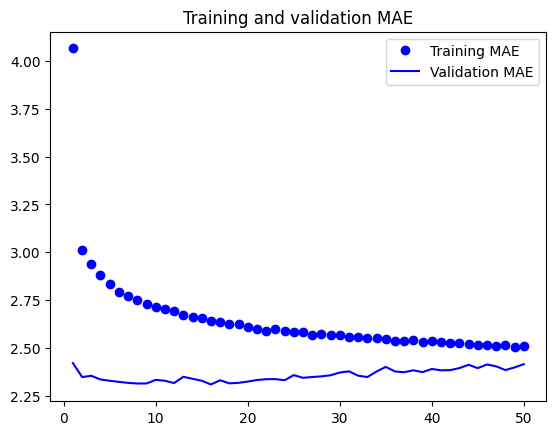

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### stacking multiple RNNs

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras",
save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
epochs=50,
validation_data=val_dataset,
callbacks=callbacks)

model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 305s 360ms/step - loss: 27.1714 - mae: 3.8375 - val_loss: 9.5800 - val_mae: 2.3905
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 294s 358ms/step - loss: 14.2812 - mae: 2.9300 - val_loss: 8.8876 - val_mae: 2.3139
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 295s 360ms/step - loss: 13.5933 - mae: 2.8546 - val_loss: 8.7194 - val_mae: 2.2927
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 313s 350ms/step - loss: 13.0403 - mae: 2.7987 - val_loss: 9.0017 - val_mae: 2.3412
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 289s 353ms/step - loss: 12.6735 - mae: 2.7602 - val_loss: 8.8616 - val_mae: 2.3182
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 291s 354ms/step - loss: 12.3174 - mae: 2.7221 - val_loss: 8.5813 - val_mae: 2.2819
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 286s 349ms/step - loss: 11.9757 - mae: 2.6857 - val_loss: 8.6764 - val_mae: 2.2978
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 293s 357ms/step - loss: 11.7198 - mae: 2.6566 - val_loss: 9.1174 - val_mae: 2.3607
Epoch 9/50
819/8

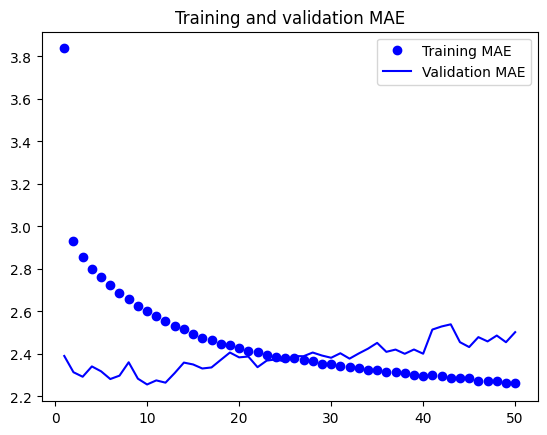

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()